# Windowing Demo

<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_197880/1615753899.py:33: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Delay (Wavelengths $\lambda$)')
/tmp/ipykernel_197880/1615753899.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Spatial Frequency (Wavenumber $1/\lambda$)')


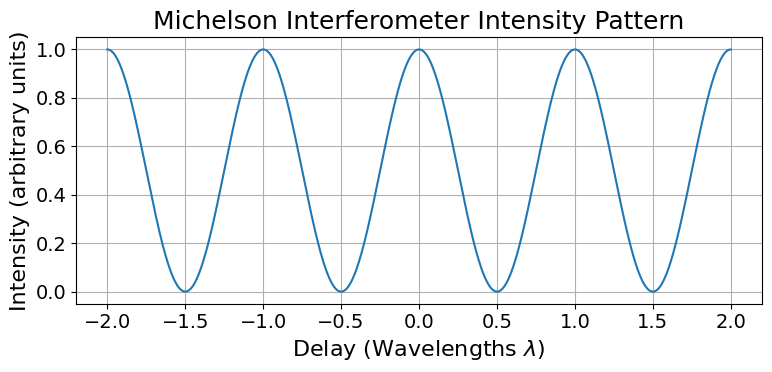

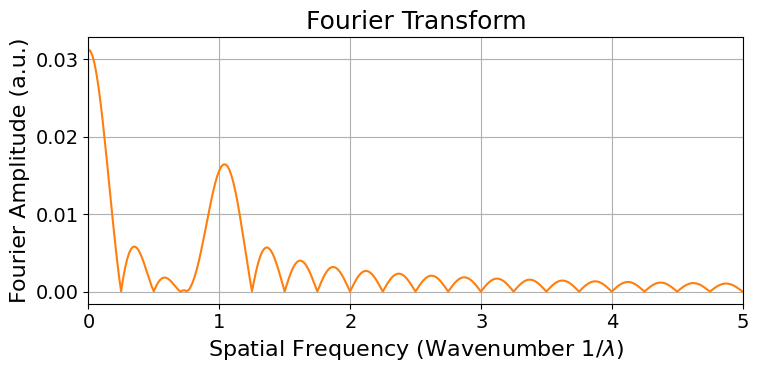

In [2]:
import numpy as np
from numpy.fft import ifft, fftshift, fftfreq
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 16,        # default text
    "axes.titlesize": 18,   # figure/axes title
    "axes.labelsize": 16,   # x and y labels
    "xtick.labelsize": 14,  # x tick labels
    "ytick.labelsize": 14,  # y tick labels
    "legend.fontsize": 14   # legend
})


savedir = Path('/home/mike/Documents/Boulder_PhD/Meetings/9-5-25 Group Meeting/figs')

def interferogram_single(k, d):
    return np.cos(k * d/2 )**2

wavelength = 1  # 500 nm

k = 2 * np.pi / wavelength
d = np.linspace(-2 * wavelength, 2 * wavelength, 1000)  

pad_factor= 2**4
spectrum = np.abs(fftshift(ifft(interferogram_single(k, d), n= len(d) * pad_factor)))
freqs = fftshift(fftfreq(len(d)* pad_factor, d[1] - d[0]))


plt.figure(figsize=(8,4))
plt.plot(d, interferogram_single(k,d), color="tab:blue")
plt.xlabel('Delay (Wavelengths $\lambda$)')
plt.ylabel('Intensity (arbitrary units)')
plt.title('Michelson Interferometer Intensity Pattern')
plt.grid()
plt.tight_layout()
plt.savefig(savedir / 'single_wave_gram.svg')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(freqs, spectrum, color='tab:orange')
plt.xlim(0,5)
plt.xlabel('Spatial Frequency (Wavenumber $1/\lambda$)')
plt.ylabel('Fourier Amplitude (a.u.)')
plt.title('Fourier Transform')
plt.grid()
plt.tight_layout()
plt.savefig(savedir / 'single_wave_spec.svg')
plt.show()

<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_197880/2600035326.py:33: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Delay (Wavelengths $\lambda$)')
/tmp/ipykernel_197880/2600035326.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Spatial Frequency (Wavenumber $1/\lambda$)')


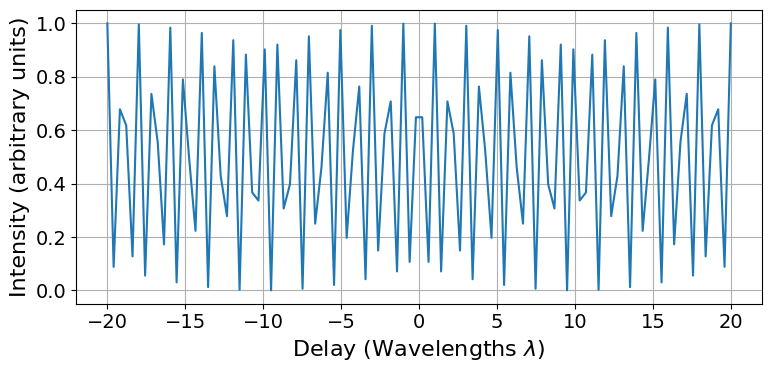

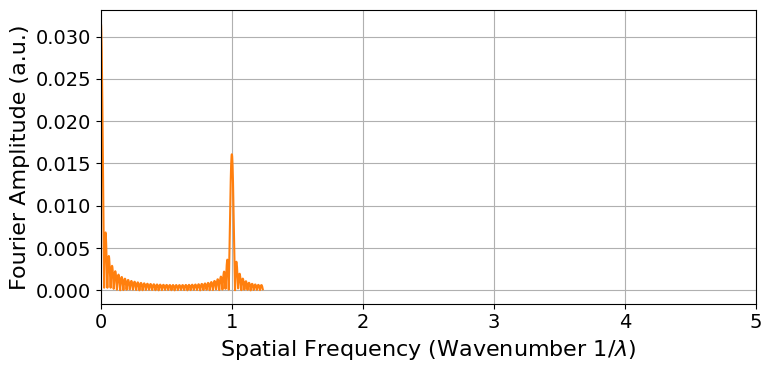

In [3]:
import numpy as np
from numpy.fft import ifft, fftshift, fftfreq
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 16,        # default text
    "axes.titlesize": 18,   # figure/axes title
    "axes.labelsize": 16,   # x and y labels
    "xtick.labelsize": 14,  # x tick labels
    "ytick.labelsize": 14,  # y tick labels
    "legend.fontsize": 14   # legend
})


savedir = Path('/home/mike/Documents/Boulder_PhD/Meetings/9-5-25 Group Meeting/figs')

def interferogram_single(k, d):
    return np.cos(k * d/2 )**2

wavelength = 1  # 500 nm

k = 2 * np.pi / wavelength
d = np.linspace(-20 * wavelength, 20 * wavelength, 100)  

pad_factor= 2**4
spectrum = np.abs(fftshift(ifft(interferogram_single(k, d), n= len(d) * pad_factor)))
freqs = fftshift(fftfreq(len(d)* pad_factor, d[1] - d[0]))


plt.figure(figsize=(8,4))
plt.plot(d, interferogram_single(k,d), color="tab:blue")
plt.xlabel('Delay (Wavelengths $\lambda$)')
plt.ylabel('Intensity (arbitrary units)')
# plt.title('Michelson Interferometer Intensity Pattern')
plt.grid()
plt.tight_layout()
plt.savefig(savedir / 'single_wave_gram_large.svg')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(freqs, spectrum, color='tab:orange')
plt.xlim(0,5)
plt.xlabel('Spatial Frequency (Wavenumber $1/\lambda$)')
plt.ylabel('Fourier Amplitude (a.u.)')
# plt.title('Fourier Transform')
plt.grid()
plt.tight_layout()
plt.savefig(savedir / 'single_wave_spec_large.svg')
plt.show()

# Coherence length demo

<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:67: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_197880/3573096874.py:67: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Spatial Frequency (Wavenumber $1/\lambda$)')


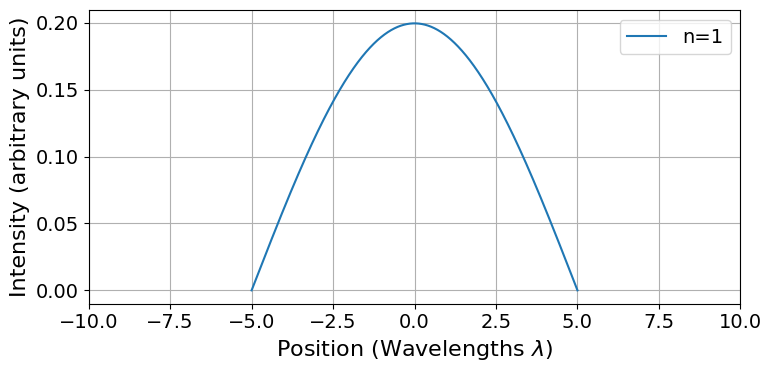

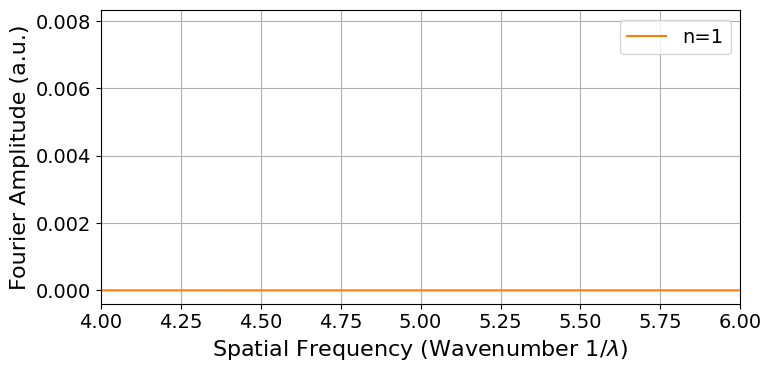

/tmp/ipykernel_197880/3573096874.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 5)


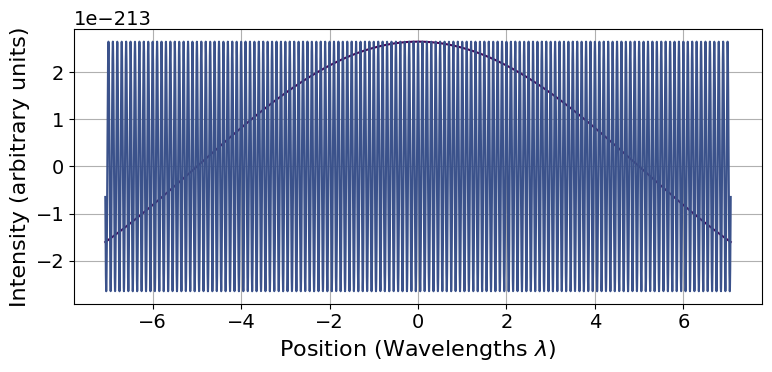

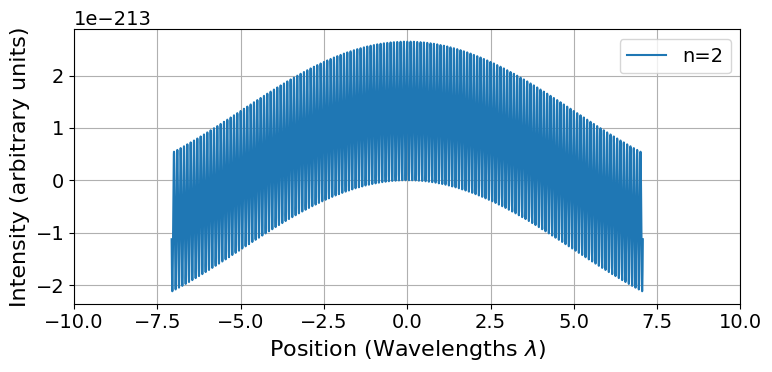

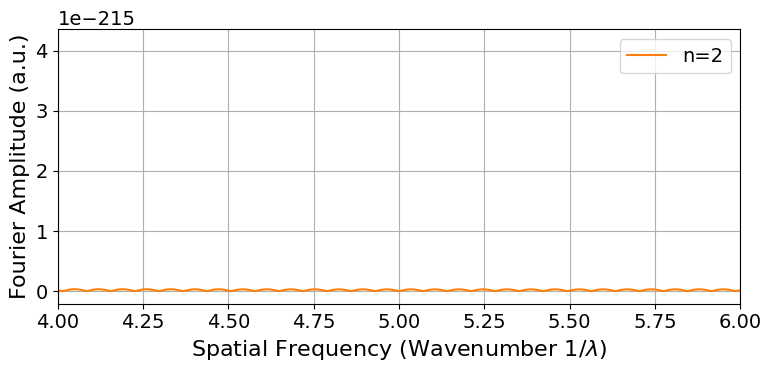

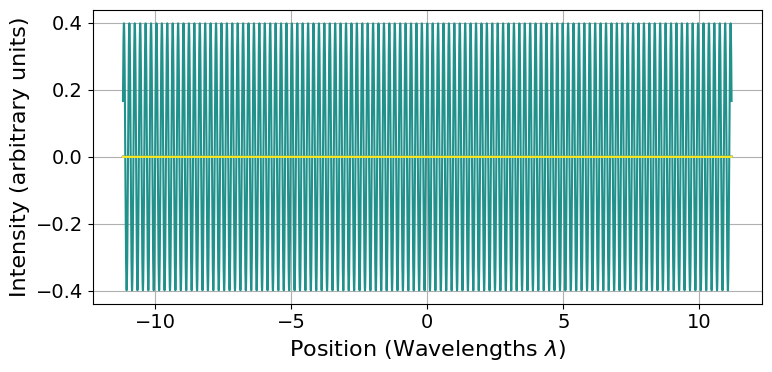

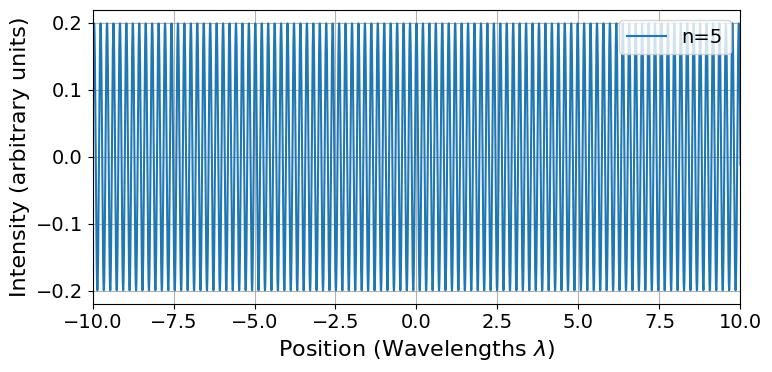

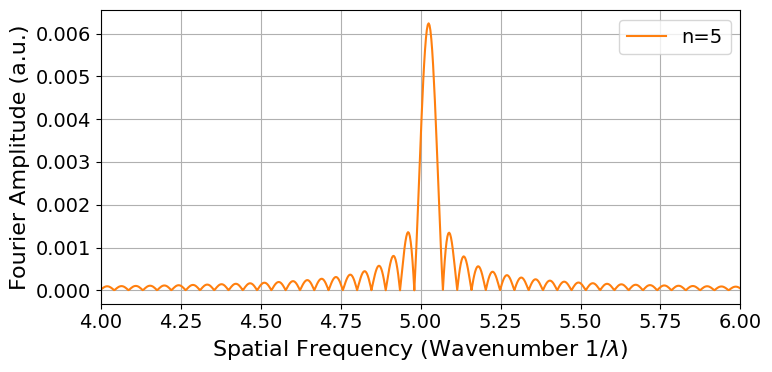

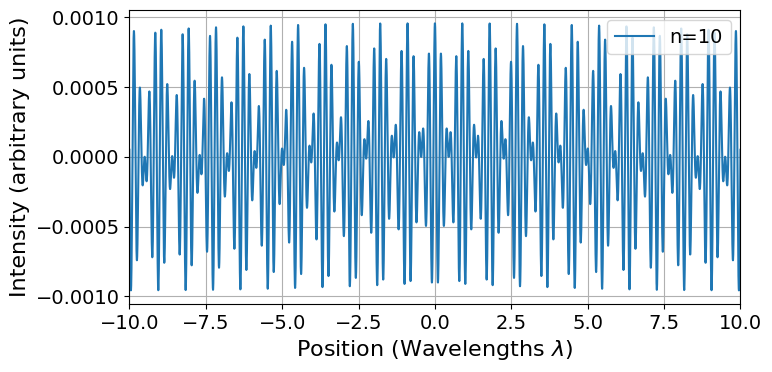

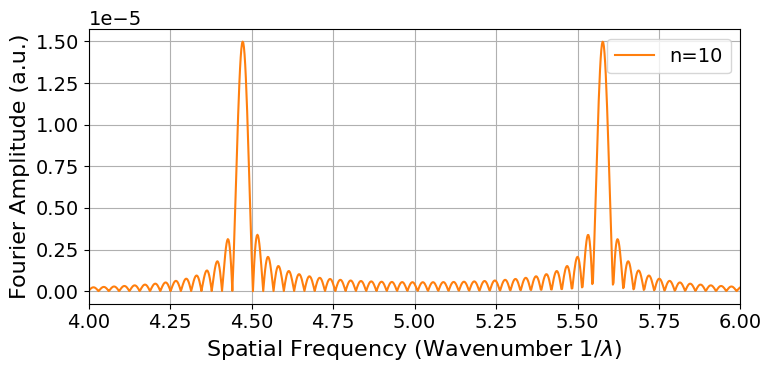

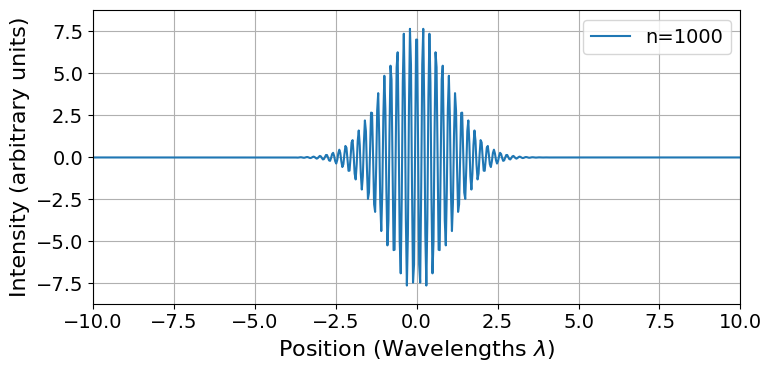

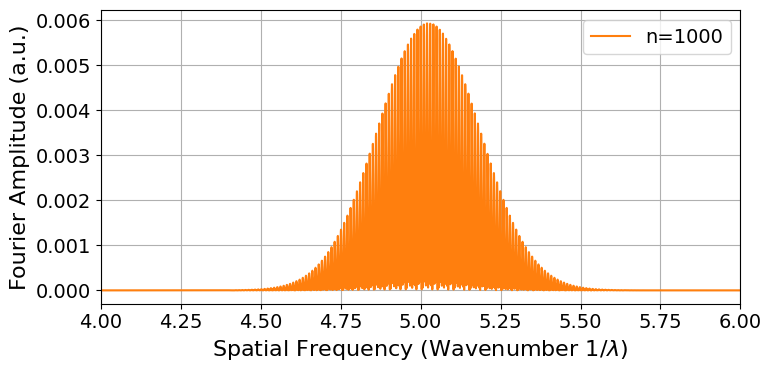

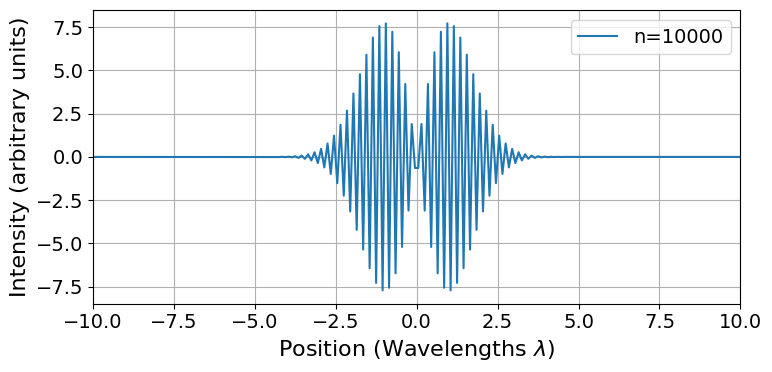

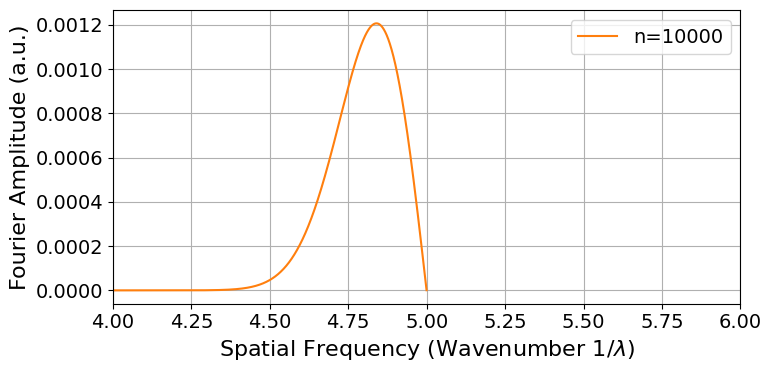

In [8]:
import numpy as np
from numpy.fft import ifft, fftshift, fftfreq
from scipy.stats import norm
import matplotlib.cm as cm
import matplotlib.pyplot as plt

def interferogram_superposition(k, d, phi, amp):
    for i in range(len(k)):
        if i == 0:
            result = amp[i] * (np.cos(k[i] * d/2  + phi[i])**2 -1/2)
        else:
            result += amp[i] * (np.cos(k[i] * d/2  + phi[i])**2 -1/2)
    return result

plt.rcParams.update({
    "font.size": 16,        # default text
    "axes.titlesize": 18,   # figure/axes title
    "axes.labelsize": 16,   # x and y labels
    "xtick.labelsize": 14,  # x tick labels
    "ytick.labelsize": 14,  # y tick labels
    "legend.fontsize": 14   # legend
})
    

for n in [1, 2, 5, 10, 1000,10000]:
    wavelength_min = .1 
    wavelength_max = 20 

    k = np.linspace(2 * np.pi / wavelength_max, 2 * np.pi / wavelength_min, n)
    phi = k ** 2 * 0
    amp = norm.pdf(k, np.mean(k), 1)

    d = np.linspace(-5 * np.sqrt(n)  , 5 * np.sqrt(n) , 10000)  

    pad_factor= 2**4
    spectrum = np.abs(fftshift(ifft(interferogram_superposition(k, d, phi, amp), n= len(d) * pad_factor)))
    freqs = fftshift(fftfreq(len(d)* pad_factor, d[1] - d[0]))
    if n in [2, 5]:
        cmap = cm.get_cmap('viridis', 5)
        plt.figure(figsize=(8,4))
        for i in range(len(k)):
            plt.plot(d, amp[i]* np.cos(k[i] * d), color=cmap(i))
        plt.xlabel(r'Position (Wavelengths $\lambda$)')
        plt.ylabel('Intensity (arbitrary units)')
        # plt.title('Michelson Interferometer Intensity Pattern')
        plt.grid()
        plt.tight_layout()
        # plt.savefig(savedir / f'{n}_sum.svg')
        plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(d, interferogram_superposition(k,d, phi, amp), label = f'n={n}')
    plt.xlabel(r'Position (Wavelengths $\lambda$)')
    plt.ylabel('Intensity (arbitrary units)')
    plt.xlim(-10,10)
    # plt.title('Michelson Interferometer Intensity Pattern')
    plt.grid()
    plt.legend(loc='upper right')
    plt.tight_layout()
    # plt.savefig(savedir / f'{n}_gram.svg')
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(freqs, spectrum, label = f'n={n}', color='tab:orange')
    plt.xlim(4,6)
    # plt.ylim(0,2000)
    plt.xlabel('Spatial Frequency (Wavenumber $1/\lambda$)')
    plt.ylabel('Fourier Amplitude (a.u.)')
    # plt.title('Fourier Transform of Intensity Pattern')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    # plt.savefig(savedir / f'{n}_spec.svg')
    plt.show()

<>:57: SyntaxWarning: invalid escape sequence '\l'
<>:57: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_50795/2629645604.py:57: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Spatial Frequency (Wavenumber $1/\lambda$)')


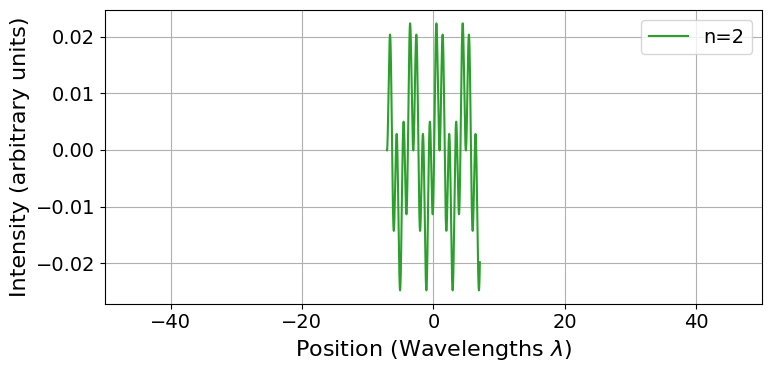

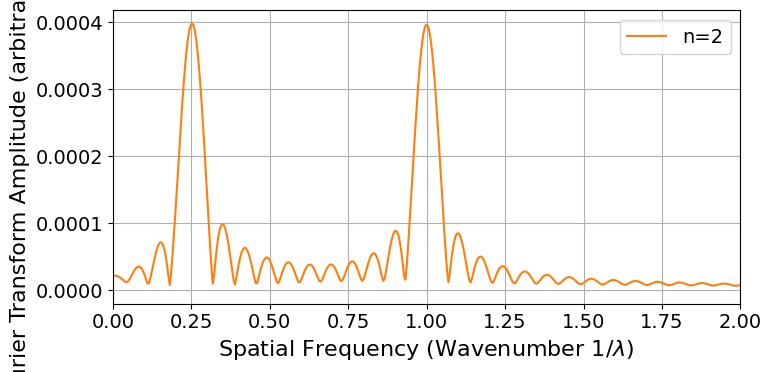

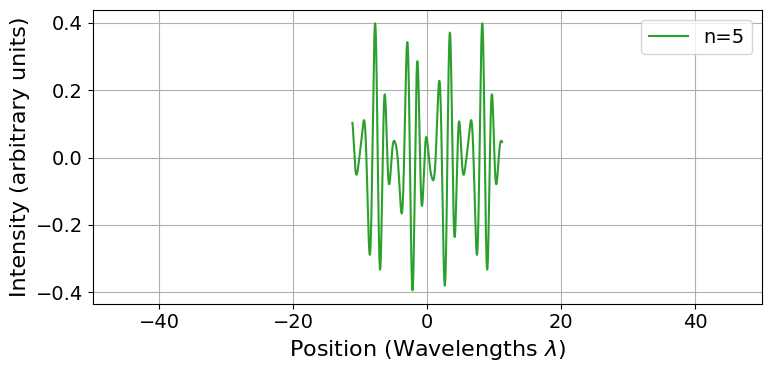

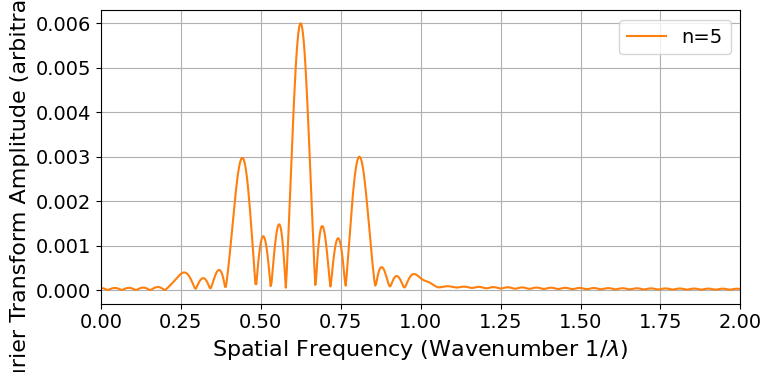

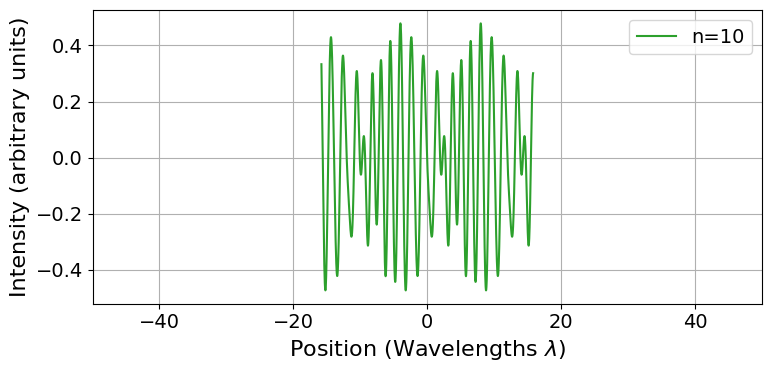

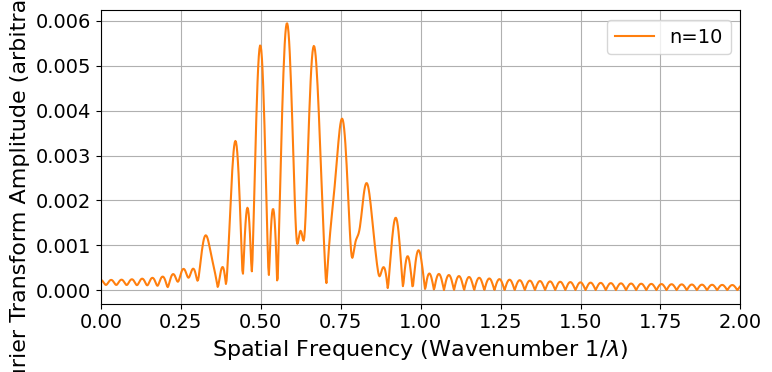

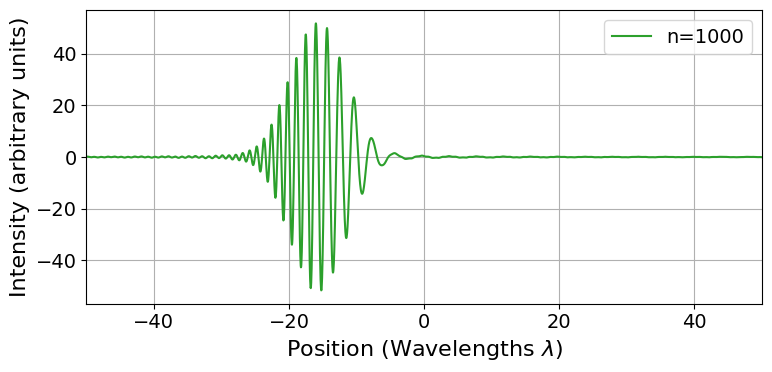

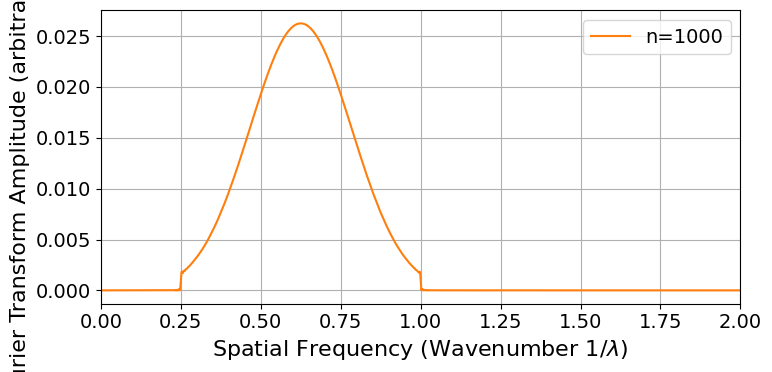

In [22]:
import numpy as np
from numpy.fft import ifft, fftshift, fftfreq
from scipy.stats import norm
from scipy.fft import dct

import matplotlib.pyplot as plt

def interferogram(E, d):
    for i in range(len(k)):
        if i == 0:
            result = amp[i] * np.cos(k[i] * d/2  + phi[i])**2
        else:
            result += amp[i] * np.cos(k[i] * d/2  + phi[i])**2
    return result
    

plt.rcParams.update({
    "font.size": 16,        # default text
    "axes.titlesize": 18,   # figure/axes title
    "axes.labelsize": 16,   # x and y labels
    "xtick.labelsize": 14,  # x tick labels
    "ytick.labelsize": 14,  # y tick labels
    "legend.fontsize": 14   # legend
})

for n in [2, 5, 10, 1000]:
    wavelength_min = 1 
    wavelength_max = 4 

    k = np.linspace(2 * np.pi / wavelength_max, 2 * np.pi / wavelength_min, n)
    phi = k ** 2 
    amp = norm.pdf(k, np.mean(k), 1)

    d = np.linspace(-5 * np.sqrt(n)  , 5 * np.sqrt(n) , 10000)  

    pad_factor= 2**4
    spectrum = np.abs(fftshift(ifft(interferogram_superposition(k, d, phi, amp), n= len(d) * pad_factor)))
    freqs = fftshift(fftfreq(len(d)* pad_factor, d[1] - d[0]))


    plt.figure(figsize=(8,4))
    plt.plot(d, interferogram_superposition(k,d, phi, amp), label = f'n={n}', color="tab:green")
    plt.xlabel(r'Position (Wavelengths $\lambda$)')
    plt.ylabel('Intensity (arbitrary units)')
    # plt.title('Michelson Interferometer Intensity Pattern')
    plt.grid()
    plt.xlim(-50,50)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(savedir / f'{n}_gram_chirped.svg')
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(freqs, spectrum, label = f'n={n}', color='tab:orange')
    plt.xlim(0,2)
    # plt.ylim(0,2000)
    plt.xlabel('Spatial Frequency (Wavenumber $1/\lambda$)')
    plt.ylabel('Fourier Transform Amplitude (arbitrary units)')
    # plt.title('Fourier Transform of Intensity Pattern')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.savefig(savedir / f'{n}_spec_chirped.svg')
    plt.show()